In [101]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tamargurabanidze/dataset-house/sample_submission.csv
/kaggle/input/datasets/tamargurabanidze/dataset-house/data_description.txt
/kaggle/input/datasets/tamargurabanidze/dataset-house/train.csv
/kaggle/input/datasets/tamargurabanidze/dataset-house/test.csv


In [187]:
# House Prices Project

In [102]:
!pip install mlflow dagshub

In [103]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/tamargurabanidze/dataset-house/train.csv")


df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [104]:
import dagshub
import mlflow

In [105]:
import dagshub

dagshub.init(
    repo_owner="tgura23",
    repo_name="ml_assignment_housePrices",
    mlflow=True
)

import mlflow
mlflow.set_experiment("house_prices_clean_dagshub")

Initialized MLflow to track repo "tgura23/ml_assignment_housePrices"

Repository tgura23/ml_assignment_housePrices initialized!

<Experiment: artifact_location='mlflow-artifacts:/4ecb8f0983ea4e69a05084a89e14e61a', creation_time=1776087711748, experiment_id='4', last_update_time=1776087711748, lifecycle_stage='active', name='house_prices_clean_dagshub', tags={}, trace_location=None, workspace='default'>

In [106]:
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

In [107]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (1168, 80)
Test size:  (292, 80)


In [108]:
print(X_train.describe())

                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1168.000000  1168.000000   951.000000    1168.000000  1168.000000   
mean    730.904966    56.849315    70.343849   10689.642123     6.121575   
std     425.369088    42.531862    24.897021   10759.366198     1.367619   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     360.750000    20.000000    59.000000    7587.250000     5.000000   
50%     732.500000    50.000000    70.000000    9600.000000     6.000000   
75%    1101.750000    70.000000    80.000000   11700.000000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1168.000000  1168.000000   1168.000000  1162.000000  1168.000000  ...   
mean      5.584760  1970.965753   1984.897260   103.771945   446.023973  ...   
std       1.116062    30.675495     20.733955   173.032238   459.070977  ..

In [109]:
print(X_train.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      217
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
Length: 80, dtype: int64


In [110]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    951 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          74 non-null     object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64  
 18  OverallCond

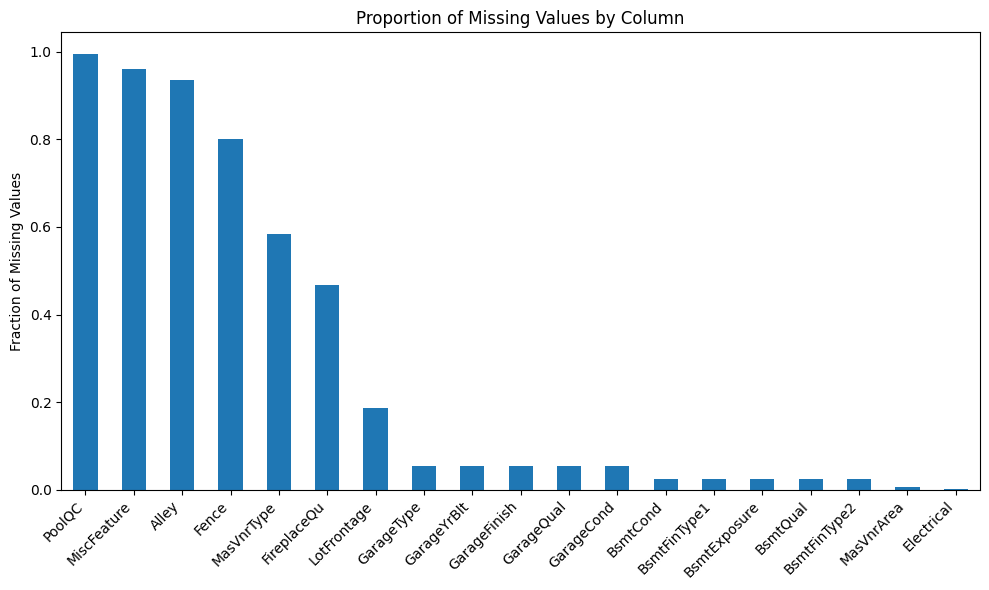

In [111]:
import matplotlib.pyplot as plt

null_ratio = X_train.isna().sum() / X_train.shape[0]
null_ratio = null_ratio[null_ratio > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
null_ratio.plot(kind='bar')
plt.title('Proportion of Missing Values by Column')
plt.ylabel('Fraction of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [112]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
num_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns ({len(num_cols)}): {num_cols}")

Categorical columns (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Numerical columns (37): ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageC

<Figure size 1500x1000 with 0 Axes>

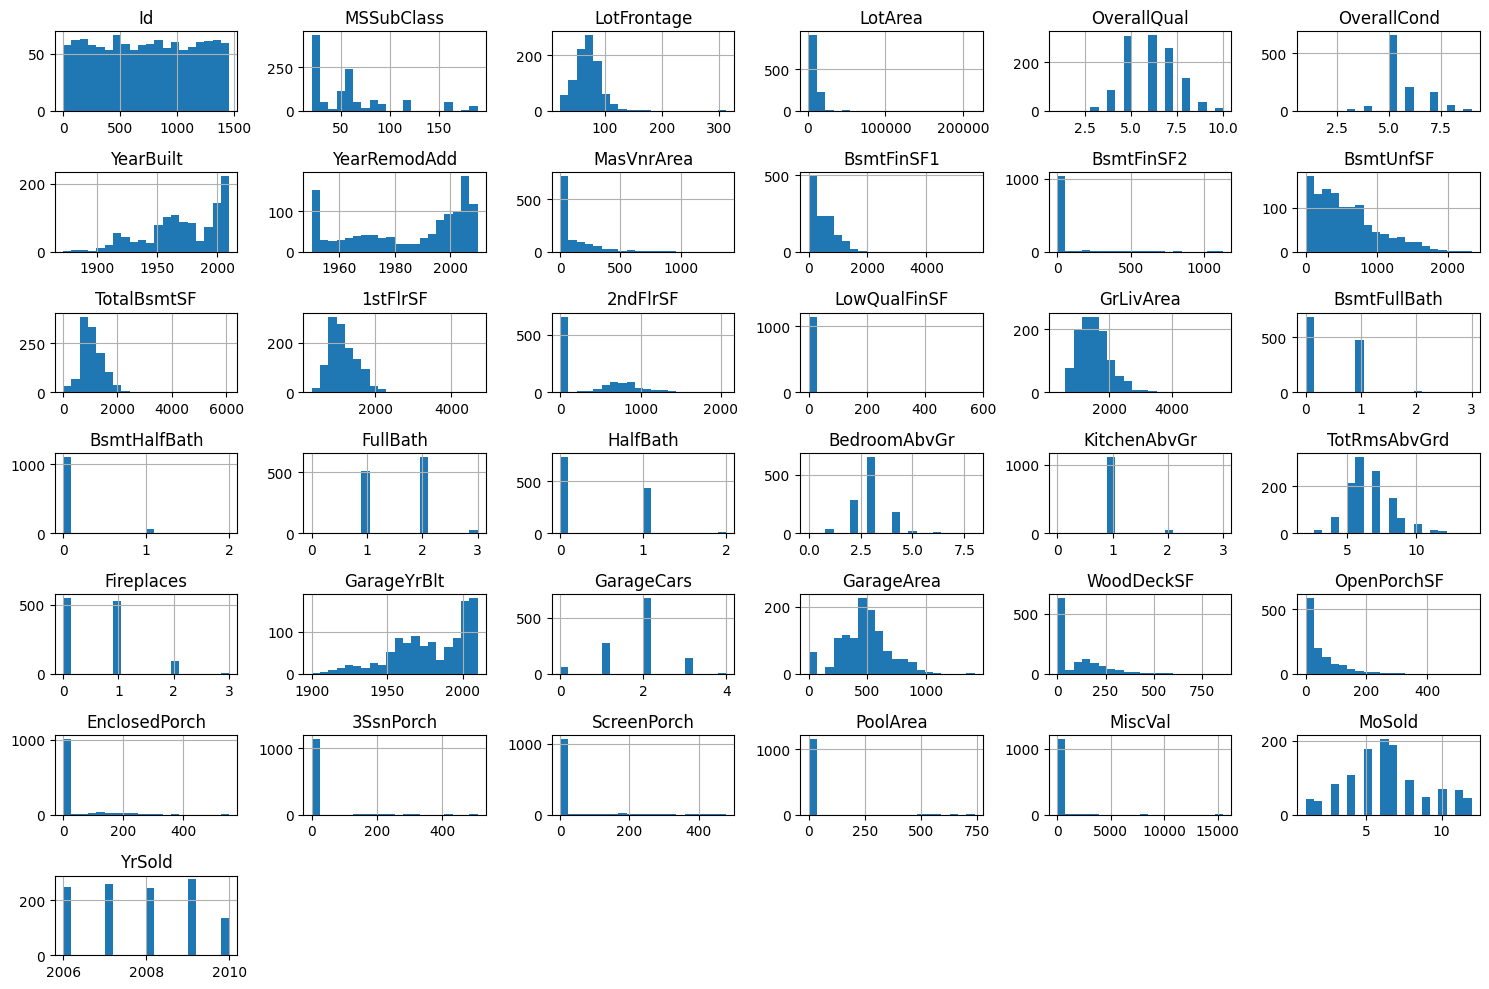

In [113]:
import matplotlib.pyplot as plt

X_train[num_cols].describe()

plt.figure(figsize=(15, 10))
X_train[num_cols].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

In [188]:
#Cleaning

In [114]:
cols_to_drop = ["PoolQC", "MiscFeature", "Id"]

X_train = X_train.drop(columns=cols_to_drop, errors="ignore")
X_test = X_test.drop(columns=cols_to_drop, errors="ignore")


In [115]:
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
X_train[cat_cols].isnull().sum().sort_values(ascending=False)

Alley            1094
Fence             935
MasVnrType        683
FireplaceQu       547
GarageType         64
GarageFinish       64
GarageCond         64
GarageQual         64
BsmtQual           28
BsmtFinType1       28
BsmtFinType2       28
BsmtExposure       28
BsmtCond           28
Electrical          1
LotShape            0
Street              0
MSZoning            0
Neighborhood        0
LandSlope           0
LotConfig           0
Utilities           0
LandContour         0
Condition1          0
BldgType            0
Condition2          0
ExterCond           0
ExterQual           0
Foundation          0
HouseStyle          0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
Functional          0
KitchenQual         0
HeatingQC           0
CentralAir          0
Heating             0
PavedDrive          0
SaleType            0
SaleCondition       0
dtype: int64

In [116]:
for col in ["BsmtQual", "BsmtFinType1", "BsmtFinType2", "BsmtExposure", "BsmtCond"]:
    print(col)
    print(X[col].unique())
    print("-" * 40)

BsmtQual
['Gd' 'TA' 'Ex' nan 'Fa']
----------------------------------------
BsmtFinType1
['GLQ' 'ALQ' 'Unf' 'Rec' 'BLQ' nan 'LwQ']
----------------------------------------
BsmtFinType2
['Unf' 'BLQ' nan 'ALQ' 'Rec' 'LwQ' 'GLQ']
----------------------------------------
BsmtExposure
['No' 'Gd' 'Mn' 'Av' nan]
----------------------------------------
BsmtCond
['TA' 'Gd' nan 'Fa' 'Po']
----------------------------------------


In [117]:
cols = ["BsmtQual", "BsmtFinType1", "BsmtFinType2", "BsmtExposure", "BsmtCond"]

for col in cols:
    print("\n", col)
    print(X_train[col].value_counts(dropna=False))


 BsmtQual
BsmtQual
TA     521
Gd     493
Ex      97
Fa      29
NaN     28
Name: count, dtype: int64

 BsmtFinType1
BsmtFinType1
Unf    345
GLQ    328
ALQ    178
BLQ    123
Rec    104
LwQ     62
NaN     28
Name: count, dtype: int64

 BsmtFinType2
BsmtFinType2
Unf    1009
Rec      46
LwQ      36
NaN      28
BLQ      22
ALQ      17
GLQ      10
Name: count, dtype: int64

 BsmtExposure
BsmtExposure
No     769
Av     175
Gd     103
Mn      93
NaN     28
Name: count, dtype: int64

 BsmtCond
BsmtCond
TA     1045
Gd       55
Fa       39
NaN      28
Po        1
Name: count, dtype: int64


In [118]:
basement_cols = [
    "BsmtQual",
    "BsmtFinType1",
    "BsmtFinType2",
    "BsmtExposure",
    "BsmtCond"
]

X_train[basement_cols] = X_train[basement_cols].fillna("None")
X_test[basement_cols] = X_test[basement_cols].fillna("None")

In [119]:
cols = ["GarageType", "GarageFinish", "GarageCond", "GarageQual"]

for col in cols:
    print("\n", col)
    print(X_train[col].value_counts(dropna=False))


 GarageType
GarageType
Attchd     693
Detchd     308
BuiltIn     74
NaN         64
Basment     16
CarPort      7
2Types       6
Name: count, dtype: int64

 GarageFinish
GarageFinish
Unf    480
RFn    339
Fin    285
NaN     64
Name: count, dtype: int64

 GarageCond
GarageCond
TA     1061
NaN      64
Fa       27
Gd        9
Po        5
Ex        2
Name: count, dtype: int64

 GarageQual
GarageQual
TA     1050
NaN      64
Fa       36
Gd       13
Ex        3
Po        2
Name: count, dtype: int64


In [120]:
garage_cols = ["GarageType", "GarageFinish", "GarageCond", "GarageQual"]

X_train[garage_cols] = X_train[garage_cols].fillna("None")
X_test[garage_cols] = X_test[garage_cols].fillna("None")

In [121]:
cols = ["Alley", "Fence", "MasVnrType", "FireplaceQu"]

for col in cols:
    print("\n", col)
    print(X_train[col].value_counts(dropna=False))



 Alley
Alley
NaN     1094
Grvl      44
Pave      30
Name: count, dtype: int64

 Fence
Fence
NaN      935
MnPrv    128
GdPrv     50
GdWo      46
MnWw       9
Name: count, dtype: int64

 MasVnrType
MasVnrType
NaN        683
BrkFace    366
Stone      106
BrkCmn      13
Name: count, dtype: int64

 FireplaceQu
FireplaceQu
NaN    547
Gd     305
TA     252
Fa      27
Ex      21
Po      16
Name: count, dtype: int64


In [122]:
import pandas as pd

train_temp = X_train.copy()
train_temp["SalePrice"] = y_train
cols = ["Alley", "Fence", "MasVnrType", "FireplaceQu"]

for col in cols:
    print("\n", col)
    print(train_temp.groupby(col)["SalePrice"].mean().sort_values())


 Alley
Alley
Grvl    124419.409091
Pave    169128.266667
Name: SalePrice, dtype: float64

 Fence
Fence
MnWw     135461.111111
GdWo     140732.239130
MnPrv    152134.375000
GdPrv    182234.400000
Name: SalePrice, dtype: float64

 MasVnrType
MasVnrType
BrkCmn     150023.076923
BrkFace    201804.032787
Stone      261037.471698
Name: SalePrice, dtype: float64

 FireplaceQu
FireplaceQu
Po    133361.437500
Fa    168772.222222
TA    205989.257937
Gd    224858.645902
Ex    317838.095238
Name: SalePrice, dtype: float64


In [123]:
cols = ["Alley", "Fence", "MasVnrType", "FireplaceQu"]

X_train[cols] = X_train[cols].fillna("None")
X_test[cols] = X_test[cols].fillna("None")

In [124]:
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
X_train[cat_cols].isnull().sum().sort_values(ascending=False)

Electrical       1
Street           0
Alley            0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
MSZoning         0
Neighborhood     0
Condition1       0
BldgType         0
Condition2       0
RoofStyle        0
RoofMatl         0
Exterior1st      0
HouseStyle       0
MasVnrType       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
Exterior2nd      0
BsmtFinType1     0
BsmtFinType2     0
HeatingQC        0
Heating          0
CentralAir       0
KitchenQual      0
Functional       0
FireplaceQu      0
GarageType       0
GarageFinish     0
GarageQual       0
GarageCond       0
PavedDrive       0
Fence            0
SaleType         0
SaleCondition    0
dtype: int64

In [125]:
mode_value = X_train["Electrical"].mode()[0]
X_train["Electrical"] = X_train["Electrical"].fillna(mode_value)
X_test["Electrical"] = X_test["Electrical"].fillna(mode_value)

In [126]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
print(num_cols)

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')


In [127]:
X_train[num_cols].isnull().sum().sort_values(ascending=False)

LotFrontage      217
GarageYrBlt       64
MasVnrArea         6
MSSubClass         0
OverallQual        0
LotArea            0
YearBuilt          0
OverallCond        0
BsmtFinSF1         0
BsmtFinSF2         0
BsmtUnfSF          0
YearRemodAdd       0
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
TotalBsmtSF        0
HalfBath           0
BedroomAbvGr       0
TotRmsAbvGrd       0
KitchenAbvGr       0
Fireplaces         0
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
dtype: int64

In [128]:
num_cols = ["LotFrontage", "GarageYrBlt", "MasVnrArea"]

X_train[num_cols].describe()

,LotFrontage,GarageYrBlt,MasVnrArea
count,951.000000,1104.000000,1162.000000
mean,70.343849,1978.662138,103.771945
std,24.897021,24.728938,173.032238
min,21.000000,1900.000000,0.000000
25%,59.000000,1961.750000,0.000000
50%,70.000000,1980.000000,0.000000
75%,80.000000,2002.000000,166.000000
max,313.000000,2010.000000,1378.000000


In [129]:
for col in ["LotFrontage", "GarageYrBlt", "MasVnrArea"]:
    print("\n", col)
    print("Missing:", X_train[col].isnull().sum())
    print(X_train[col].describe())


 LotFrontage
Missing: 217
count    951.000000
mean      70.343849
std       24.897021
min       21.000000
25%       59.000000
50%       70.000000
75%       80.000000
max      313.000000
Name: LotFrontage, dtype: float64

 GarageYrBlt
Missing: 64
count    1104.000000
mean     1978.662138
std        24.728938
min      1900.000000
25%      1961.750000
50%      1980.000000
75%      2002.000000
max      2010.000000
Name: GarageYrBlt, dtype: float64

 MasVnrArea
Missing: 6
count    1162.000000
mean      103.771945
std       173.032238
min         0.000000
25%         0.000000
50%         0.000000
75%       166.000000
max      1378.000000
Name: MasVnrArea, dtype: float64


In [130]:
fill_value = X_train["LotFrontage"].median()
X_train["LotFrontage"] = X_train["LotFrontage"].fillna(fill_value)
X_test["LotFrontage"] = X_test["LotFrontage"].fillna(fill_value)

In [131]:
X_train["GarageYrBlt"] = X_train["GarageYrBlt"].fillna(0)
X_test["GarageYrBlt"] = X_test["GarageYrBlt"].fillna(0)

In [132]:
X_train["MasVnrArea"] = X_train["MasVnrArea"].fillna(0)
X_test["MasVnrArea"] = X_test["MasVnrArea"].fillna(0)

In [133]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1168 non-null   int64  
 1   MSZoning       1168 non-null   object 
 2   LotFrontage    1168 non-null   float64
 3   LotArea        1168 non-null   int64  
 4   Street         1168 non-null   object 
 5   Alley          1168 non-null   object 
 6   LotShape       1168 non-null   object 
 7   LandContour    1168 non-null   object 
 8   Utilities      1168 non-null   object 
 9   LotConfig      1168 non-null   object 
 10  LandSlope      1168 non-null   object 
 11  Neighborhood   1168 non-null   object 
 12  Condition1     1168 non-null   object 
 13  Condition2     1168 non-null   object 
 14  BldgType       1168 non-null   object 
 15  HouseStyle     1168 non-null   object 
 16  OverallQual    1168 non-null   int64  
 17  OverallCond    1168 non-null   int64  
 18  YearBuilt  

In [134]:
print(X_test.info())

<class 'pandas.core.frame.DataFrame'>
Index: 292 entries, 892 to 722
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     292 non-null    int64  
 1   MSZoning       292 non-null    object 
 2   LotFrontage    292 non-null    float64
 3   LotArea        292 non-null    int64  
 4   Street         292 non-null    object 
 5   Alley          292 non-null    object 
 6   LotShape       292 non-null    object 
 7   LandContour    292 non-null    object 
 8   Utilities      292 non-null    object 
 9   LotConfig      292 non-null    object 
 10  LandSlope      292 non-null    object 
 11  Neighborhood   292 non-null    object 
 12  Condition1     292 non-null    object 
 13  Condition2     292 non-null    object 
 14  BldgType       292 non-null    object 
 15  HouseStyle     292 non-null    object 
 16  OverallQual    292 non-null    int64  
 17  OverallCond    292 non-null    int64  
 18  YearBuilt    

In [ ]:
#FEATURE ENGINEERING

In [135]:
cols = [
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond",
    "HeatingQC", "KitchenQual", "FireplaceQu",
    "GarageQual", "GarageCond"
]

for col in cols:
    print("\n", col)
    print(X_train[col].unique())


 ExterQual
['TA' 'Gd' 'Ex' 'Fa']

 ExterCond
['Gd' 'TA' 'Ex' 'Fa' 'Po']

 BsmtQual
['TA' 'Gd' 'Fa' 'None' 'Ex']

 BsmtCond
['TA' 'Fa' 'None' 'Gd' 'Po']

 HeatingQC
['TA' 'Gd' 'Ex' 'Fa' 'Po']

 KitchenQual
['TA' 'Gd' 'Ex' 'Fa']

 FireplaceQu
['None' 'TA' 'Gd' 'Fa' 'Ex' 'Po']

 GarageQual
['TA' 'None' 'Po' 'Fa' 'Gd' 'Ex']

 GarageCond
['TA' 'None' 'Po' 'Fa' 'Gd' 'Ex']


In [136]:
qual_map = {
    "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

In [137]:
qual_cols = [
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond",
    "HeatingQC", "KitchenQual", "FireplaceQu",
    "GarageQual", "GarageCond"
]

for col in qual_cols:
    X_train[col] = X_train[col].map(qual_map)
    X_test[col] = X_test[col].map(qual_map)

In [138]:
for col in qual_cols:
    print(col, X_train[col].isnull().sum())

ExterQual 0
ExterCond 0
BsmtQual 0
BsmtCond 0
HeatingQC 0
KitchenQual 0
FireplaceQu 0
GarageQual 0
GarageCond 0


In [139]:
for col in qual_cols:
    print("\n", col)
    print(X_train[col].unique())


 ExterQual
[3 4 5 2]

 ExterCond
[4 3 5 2 1]

 BsmtQual
[3 4 2 0 5]

 BsmtCond
[3 2 0 4 1]

 HeatingQC
[3 4 5 2 1]

 KitchenQual
[3 4 5 2]

 FireplaceQu
[0 3 4 2 5 1]

 GarageQual
[3 0 1 2 4 5]

 GarageCond
[3 0 1 2 4 5]


In [140]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1168 non-null   int64  
 1   MSZoning       1168 non-null   object 
 2   LotFrontage    1168 non-null   float64
 3   LotArea        1168 non-null   int64  
 4   Street         1168 non-null   object 
 5   Alley          1168 non-null   object 
 6   LotShape       1168 non-null   object 
 7   LandContour    1168 non-null   object 
 8   Utilities      1168 non-null   object 
 9   LotConfig      1168 non-null   object 
 10  LandSlope      1168 non-null   object 
 11  Neighborhood   1168 non-null   object 
 12  Condition1     1168 non-null   object 
 13  Condition2     1168 non-null   object 
 14  BldgType       1168 non-null   object 
 15  HouseStyle     1168 non-null   object 
 16  OverallQual    1168 non-null   int64  
 17  OverallCond    1168 non-null   int64  
 18  YearBuilt  

In [141]:
cat_cols = X_train.select_dtypes(include=["object"]).columns
print(cat_cols)

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical',
       'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence',
       'SaleType', 'SaleCondition'],
      dtype='object')


In [142]:

exp_map = {"None":0, "No":1, "Mn":2, "Av":3, "Gd":4}

bsmt_map = {
    "None":0, "Unf":1, "LwQ":2, "Rec":3,
    "BLQ":4, "ALQ":5, "GLQ":6
}

garage_map = {"None":0, "Unf":1, "RFn":2, "Fin":3}

fence_map = {"None":0, "MnWw":1, "GdWo":2, "MnPrv":3, "GdPrv":4}

lotshape_map = {"IR3":0, "IR2":1, "IR1":2, "Reg":3}

landslope_map = {"Sev":0, "Mod":1, "Gtl":2}

paved_map = {"N":0, "P":1, "Y":2}


ord_cols_maps = {
    "BsmtExposure": exp_map,
    "BsmtFinType1": bsmt_map,
    "BsmtFinType2": bsmt_map,
    "GarageFinish": garage_map,
    "Fence": fence_map,
    "LotShape": lotshape_map,
    "LandSlope": landslope_map,
    "PavedDrive": paved_map
}

for col, mapping in ord_cols_maps.items():
    X_train[col] = X_train[col].map(mapping)
    X_test[col] = X_test[col].map(mapping)

In [143]:
cat_cols = X_train.select_dtypes(include=["object"]).columns
print(cat_cols)

Index(['MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities', 'LotConfig',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'Foundation', 'Heating', 'CentralAir', 'Electrical', 'Functional',
       'GarageType', 'SaleType', 'SaleCondition'],
      dtype='object')


In [144]:
for col in ord_cols_maps:
    print("\n", col)
    print(X_train[col].unique())


 BsmtExposure
[1 3 4 2 0]

 BsmtFinType1
[3 1 5 2 4 6 0]

 BsmtFinType2
[1 2 3 4 0 6 5]

 GarageFinish
[2 0 1 3]

 Fence
[0 3 2 4 1]

 LotShape
[3 2 1 0]

 LandSlope
[2 1 0]

 PavedDrive
[2 1 0]


In [145]:
X_train["CentralAir"] = X_train["CentralAir"].map({"N":0, "Y":1})
X_test["CentralAir"] = X_test["CentralAir"].map({"N":0, "Y":1})

In [146]:
X_train["Street"] = X_train["Street"].map({"Grvl":0, "Pave":1})
X_test["Street"] = X_test["Street"].map({"Grvl":0, "Pave":1})

In [147]:
cat_cols = X_train.select_dtypes(include=["object"]).columns
print(cat_cols)

Index(['MSZoning', 'Alley', 'LandContour', 'Utilities', 'LotConfig',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'Foundation', 'Heating', 'Electrical', 'Functional', 'GarageType',
       'SaleType', 'SaleCondition'],
      dtype='object')


In [148]:
cols = [
    'MSZoning', 'Alley', 'LandContour', 'Utilities', 'LotConfig',
    'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
    'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
    'Foundation', 'Heating', 'Electrical', 'Functional', 'GarageType',
    'SaleType', 'SaleCondition'
]

for col in cols:
    print("\n", col)
    print(X_train[col].unique())


 MSZoning
['RL' 'RM' 'FV' 'RH' 'C (all)']

 Alley
['None' 'Pave' 'Grvl']

 LandContour
['Lvl' 'Bnk' 'HLS' 'Low']

 Utilities
['AllPub' 'NoSeWa']

 LotConfig
['Inside' 'Corner' 'CulDSac' 'FR2' 'FR3']

 Neighborhood
['NAmes' 'Gilbert' 'Edwards' 'SWISU' 'CollgCr' 'IDOTRR' 'NWAmes' 'Somerst'
 'Sawyer' 'Crawfor' 'OldTown' 'Timber' 'BrkSide' 'SawyerW' 'NridgHt'
 'Mitchel' 'NoRidge' 'Blmngtn' 'BrDale' 'NPkVill' 'Veenker' 'ClearCr'
 'StoneBr' 'MeadowV' 'Blueste']

 Condition1
['Norm' 'Feedr' 'RRAn' 'Artery' 'PosA' 'PosN' 'RRAe' 'RRNn' 'RRNe']

 Condition2
['Norm' 'RRNn' 'PosA' 'Feedr' 'RRAe' 'PosN' 'Artery' 'RRAn']

 BldgType
['1Fam' 'Duplex' 'TwnhsE' '2fmCon' 'Twnhs']

 HouseStyle
['1Story' '2Story' '1.5Fin' 'SFoyer' 'SLvl' '1.5Unf' '2.5Unf' '2.5Fin']

 RoofStyle
['Gable' 'Hip' 'Mansard' 'Gambrel' 'Flat' 'Shed']

 RoofMatl
['CompShg' 'WdShngl' 'WdShake' 'Metal' 'Tar&Grv' 'ClyTile' 'Roll']

 Exterior1st
['MetalSd' 'VinylSd' 'Wd Sdng' 'BrkFace' 'CemntBd' 'Plywood' 'HdBoard'
 'Stucco' 'WdShing'

In [149]:
woe_cols = [
    "Neighborhood",
    "MSZoning",
    "SaleType",
    "SaleCondition",
    "Exterior1st",
    "Exterior2nd",
    "GarageType"
]

X_train = pd.get_dummies(X_train, columns=woe_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=woe_cols, drop_first=True)

# align columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [186]:
print("TOTAL FEATURES:", len(X_train_final.columns))
print("\nFINAL FEATURE LIST:\n")

for i, col in enumerate(X_train_final.columns):
    print(i, col)

TOTAL FEATURES: 40

FINAL FEATURE LIST:

0 QualityScore
1 Neighborhood
2 TotalBsmtSF
3 OverallQual
4 BsmtFinSF1
5 2ndFlrSF
6 1stFlrSF
7 BsmtQual
8 GarageArea
9 LotFrontage
10 YearBuilt
11 RemodAge
12 GarageYrBlt
13 LogLotArea
14 BsmtUnfSF
15 LotArea
16 TotalBath
17 KitchenQual
18 OpenPorchSF
19 TotalPorch
20 WoodDeckSF
21 BsmtExposure
22 GarageFinish
23 MasVnrArea
24 MSZoning
25 FireplaceQu
26 ExterQual
27 BsmtFinType1
28 Exterior2nd
29 SaleCondition
30 GarageType
31 TotRmsAbvGrd
32 OverallCond
33 CentralAir
34 Exterior1st
35 MSSubClass
36 BedroomAbvGr
37 LotShape
38 FullBath
39 HeatingQC


In [150]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Columns: 146 entries, MSSubClass to GarageType_None
dtypes: bool(76), float64(3), int64(52), object(15)
memory usage: 734.6+ KB


In [151]:
ohe_cols = X_train_woe.select_dtypes(include="object").columns

X_train_final = pd.get_dummies(X_train_woe, columns=ohe_cols, drop_first=True)
X_test_final  = pd.get_dummies(X_test_woe, columns=ohe_cols, drop_first=True)

X_train_final, X_test_final = X_train_final.align(X_test_final, join="left", axis=1, fill_value=0)

In [152]:
print(X_train_final.select_dtypes(include="object").columns)
print(X_test_final.select_dtypes(include="object").columns)

Index([], dtype='object')
Index([], dtype='object')


In [153]:
print("Before OHE:", X_train_woe.shape)
print("After OHE:", X_train_final.shape)

Before OHE: (1168, 77)
After OHE: (1168, 131)


In [154]:
print(X_train_final.shape)
print(X_test_final.shape)
print(X_train_final.columns.equals(X_test_final.columns))

(1168, 131)
(292, 131)
True


In [155]:
X_train_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Columns: 131 entries, MSSubClass to Functional_Typ
dtypes: bool(69), float64(10), int64(52)
memory usage: 653.6 KB


In [156]:
print(X_train_final.select_dtypes(include='object').columns)

Index([], dtype='object')


In [157]:
X_train_final["HouseAge"] = X_train_final["YrSold"] - X_train_final["YearBuilt"]
X_test_final["HouseAge"]  = X_test_final["YrSold"] - X_test_final["YearBuilt"]

X_train_final["RemodAge"] = X_train_final["YrSold"] - X_train_final["YearRemodAdd"]
X_test_final["RemodAge"]  = X_test_final["YrSold"] - X_test_final["YearRemodAdd"]

In [158]:
X_train_final["TotalSF"] = (
    X_train_final["1stFlrSF"] +
    X_train_final["2ndFlrSF"] +
    X_train_final["TotalBsmtSF"]
)

X_test_final["TotalSF"] = (
    X_test_final["1stFlrSF"] +
    X_test_final["2ndFlrSF"] +
    X_test_final["TotalBsmtSF"]
)

In [159]:
X_train_final["TotalBath"] = (
    X_train_final["FullBath"] +
    0.5 * X_train_final["HalfBath"] +
    X_train_final["BsmtFullBath"] +
    0.5 * X_train_final["BsmtHalfBath"]
)

X_test_final["TotalBath"] = (
    X_test_final["FullBath"] +
    0.5 * X_test_final["HalfBath"] +
    X_test_final["BsmtFullBath"] +
    0.5 * X_test_final["BsmtHalfBath"]
)

In [160]:
X_train_final["TotalPorch"] = (
    X_train_final["OpenPorchSF"] +
    X_train_final["EnclosedPorch"] +
    X_train_final["3SsnPorch"] +
    X_train_final["ScreenPorch"]
)

X_test_final["TotalPorch"] = (
    X_test_final["OpenPorchSF"] +
    X_test_final["EnclosedPorch"] +
    X_test_final["3SsnPorch"] +
    X_test_final["ScreenPorch"]
)

In [161]:
import numpy as np

X_train_final["LogLotArea"] = np.log1p(X_train_final["LotArea"])
X_test_final["LogLotArea"]  = np.log1p(X_test_final["LotArea"])

X_train_final["LogGrLivArea"] = np.log1p(X_train_final["GrLivArea"])
X_test_final["LogGrLivArea"]  = np.log1p(X_test_final["GrLivArea"])

In [162]:
X_train_final["QualityScore"] = X_train_final["OverallQual"] * X_train_final["GrLivArea"]
X_test_final["QualityScore"]  = X_test_final["OverallQual"] * X_test_final["GrLivArea"]

In [163]:
print(X_train_final.shape)

(1168, 139)


In [164]:
print(X_train_final.shape)
print(X_test_final.shape)
print(X_train_final.columns.equals(X_test_final.columns))

(1168, 139)
(292, 139)
True


In [ ]:
#FEATURE SELECTION

In [165]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

mi = mutual_info_regression(X_train_final, y_train, random_state=42)

mi_series = pd.Series(mi, index=X_train_final.columns)
mi_series = mi_series.sort_values(ascending=False)

print(mi_series.head(20))

QualityScore    0.731258
TotalSF         0.638370
OverallQual     0.505418
Neighborhood    0.490773
LogGrLivArea    0.459259
GrLivArea       0.454951
GarageArea      0.363128
GarageCars      0.356106
TotalBsmtSF     0.345689
YearBuilt       0.342961
HouseAge        0.330221
BsmtQual        0.326153
KitchenQual     0.318175
TotalBath       0.316168
ExterQual       0.307599
1stFlrSF        0.297691
MSSubClass      0.287990
GarageFinish    0.277327
GarageYrBlt     0.270916
RemodAge        0.245575
dtype: float64


In [166]:
top_features = mi_series.head(60).index

X_train_fs = X_train_final[top_features]
X_test_fs  = X_test_final[top_features]

In [167]:
print(X_train_fs.shape)
print(X_test_fs.shape)
print(X_train_fs.columns.equals(X_test_fs.columns))

(1168, 60)
(292, 60)
True


In [168]:
import numpy as np

corr_matrix = X_train_fs.corr().abs()

# upper triangle (avoid duplicate checking)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# find highly correlated features
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

print("Features to drop:", len(to_drop))
print(to_drop[:10])

Features to drop: 9
['TotalSF', 'LogGrLivArea', 'GrLivArea', 'GarageCars', 'HouseAge', 'YearRemodAdd', 'Fireplaces', 'GarageQual', 'GarageCond']


In [169]:
X_train_fs = X_train_fs.drop(columns=to_drop)
X_test_fs  = X_test_fs.drop(columns=to_drop)

In [170]:
print(X_train_fs.shape)
print(X_test_fs.shape)
print(X_train_fs.columns.equals(X_test_fs.columns))

(1168, 51)
(292, 51)
True


In [171]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train_fs, y_train)

importances = pd.Series(model.feature_importances_, index=X_train_fs.columns)
importances = importances.sort_values(ascending=False)

In [172]:
top_features = importances.head(40).index

In [173]:
X_train_final = X_train_fs[top_features]
X_test_final  = X_test_fs[top_features]

In [174]:
print(X_train_final.shape)
print(len(X_train_final.columns))
print(X_train_final.columns.tolist())

(1168, 40)
40
['QualityScore', 'Neighborhood', 'TotalBsmtSF', 'OverallQual', 'BsmtFinSF1', '2ndFlrSF', '1stFlrSF', 'BsmtQual', 'GarageArea', 'LotFrontage', 'YearBuilt', 'RemodAge', 'GarageYrBlt', 'LogLotArea', 'BsmtUnfSF', 'LotArea', 'TotalBath', 'KitchenQual', 'OpenPorchSF', 'TotalPorch', 'WoodDeckSF', 'BsmtExposure', 'GarageFinish', 'MasVnrArea', 'MSZoning', 'FireplaceQu', 'ExterQual', 'BsmtFinType1', 'Exterior2nd', 'SaleCondition', 'GarageType', 'TotRmsAbvGrd', 'OverallCond', 'CentralAir', 'Exterior1st', 'MSSubClass', 'BedroomAbvGr', 'LotShape', 'FullBath', 'HeatingQC']


In [ ]:
#TRAINING

In [175]:
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import mlflow
import mlflow.sklearn
import dagshub
import pickle
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

In [176]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

best_model = None
best_rmse = float("inf")


In [177]:
from sklearn.ensemble import RandomForestRegressor

rf_n_estimators = [100, 200, 300]
rf_max_depths = [5, 10, None]

best_rf_rmse = float("inf")
best_rf_params = {}

for n in rf_n_estimators:
    for depth in rf_max_depths:

        run_name = f"RF_n{n}_d{depth}"

        with mlflow.start_run(run_name=run_name):

            model = RandomForestRegressor(
                n_estimators=n,
                max_depth=depth,
                random_state=42
            )

            cv_results = cross_validate(
                model,
                X_train_final,
                y_train,
                cv=cv,
                scoring=scoring
            )

            rmse = -cv_results["test_rmse"].mean()
            mae = -cv_results["test_mae"].mean()
            r2 = cv_results["test_r2"].mean()

            # ✅ clean logging
            mlflow.log_param("n_estimators", n)
            mlflow.log_param("max_depth", depth)
            mlflow.log_param("model", "RandomForest")

            mlflow.log_metric("rmse", rmse)
            mlflow.log_metric("mae", mae)
            mlflow.log_metric("r2", r2)

            model.fit(X_train_final, y_train)
            mlflow.sklearn.log_model(model, "model")

            print(f"{run_name} -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

            if rmse < best_rf_rmse:
                best_rf_rmse = rmse
                best_rf_params = {
                    "n_estimators": n,
                    "max_depth": depth,
                    "r2": r2
                }

2026/04/13 18:41:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 18:41:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RF_n100_d5 -> RMSE: 31308.6110, MAE: 19526.5552, R2: 0.8337
🏃 View run RF_n100_d5 at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4/runs/8ddd7eb2130e45269306fecef3e1e6df
🧪 View experiment at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4


2026/04/13 18:42:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 18:42:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RF_n100_d10 -> RMSE: 28914.0382, MAE: 17457.2858, R2: 0.8582
🏃 View run RF_n100_d10 at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4/runs/5c3240c6116144abb300dabc07b2c635
🧪 View experiment at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4


2026/04/13 18:42:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 18:42:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

RF_n300_d5 -> RMSE: 30991.4463, MAE: 19512.6667, R2: 0.8373
🏃 View run RF_n300_d5 at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4/runs/865d925206d64765ba743cdfb7792f10
🧪 View experiment at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4


2026/04/13 18:44:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 18:44:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RF_n300_d10 -> RMSE: 28409.0057, MAE: 17316.3961, R2: 0.8631
🏃 View run RF_n300_d10 at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4/runs/9cf9bdfd7821464b9b5734a2df11083b
🧪 View experiment at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4


2026/04/13 18:45:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 18:45:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RF_n300_dNone -> RMSE: 28356.5286, MAE: 17219.1409, R2: 0.8636
🏃 View run RF_n300_dNone at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4/runs/26e2f79be5a8472ba7db830c34268613
🧪 View experiment at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4


In [ ]:
from sklearn.linear_model import Ridge

ridge_alphas = [0.1, 1, 10, 100]

best_ridge_rmse = float("inf")
best_ridge_params = {}

for alpha in ridge_alphas:

    run_name = f"Ridge_alpha_{alpha}"

    with mlflow.start_run(run_name=run_name):

        model = Ridge(alpha=alpha)

        cv_results = cross_validate(
            model,
            X_train_final,
            y_train,
            cv=cv,
            scoring=scoring
        )

        rmse = -cv_results["test_rmse"].mean()
        mae = -cv_results["test_mae"].mean()
        r2 = cv_results["test_r2"].mean()

        # ✅ clean logging
        mlflow.log_param("alpha", alpha)
        mlflow.log_param("model", "Ridge")

        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2", r2)

        model.fit(X_train_final, y_train)
        mlflow.sklearn.log_model(model, "model")

        print(f"{run_name} -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

        if rmse < best_ridge_rmse:
            best_ridge_rmse = rmse
            best_ridge_params = {
                "alpha": alpha,
                "r2": r2
            }

2026/04/13 18:45:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 18:45:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge_alpha_0.1 -> RMSE: 35405.1172, MAE: 20455.5844, R2: 0.7817
🏃 View run Ridge_alpha_0.1 at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4/runs/b722996af2ad4a32add31e7d1196693a
🧪 View experiment at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4


2026/04/13 18:45:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 18:45:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge_alpha_1 -> RMSE: 35397.2745, MAE: 20446.2544, R2: 0.7818
🏃 View run Ridge_alpha_1 at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4/runs/b741ba674449483db5dbf24b291ca50f
🧪 View experiment at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4


2026/04/13 18:46:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 18:46:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [179]:
from xgboost import XGBRegressor

learning_rates = [0.03, 0.05, 0.1]
max_depths = [3, 4, 5]
n_estimators_list = [200, 300, 400]

best_xgb_rmse = float("inf")
best_xgb_params = {}

for lr in learning_rates:
    for depth in max_depths:
        for n in n_estimators_list:

            run_name = f"XGB_lr{lr}_d{depth}_n{n}"

            with mlflow.start_run(run_name=run_name):

                model = XGBRegressor(
                    objective="reg:squarederror",
                    learning_rate=lr,
                    max_depth=depth,
                    n_estimators=n,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=42
                )

                cv_results = cross_validate(
                    model,
                    X_train_final,
                    y_train,
                    cv=cv,
                    scoring=scoring
                )

                rmse = -cv_results["test_rmse"].mean()
                mae = -cv_results["test_mae"].mean()
                r2 = cv_results["test_r2"].mean()

                # ✅ log clean params
                mlflow.log_param("learning_rate", lr)
                mlflow.log_param("max_depth", depth)
                mlflow.log_param("n_estimators", n)
                mlflow.log_param("model", "XGBoost")

                # ✅ log metrics
                mlflow.log_metric("rmse", rmse)
                mlflow.log_metric("mae", mae)
                mlflow.log_metric("r2", r2)

                model.fit(X_train_final, y_train)
                mlflow.sklearn.log_model(model, "model")

                print(f"{run_name} -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

                # ✅ track best
                if rmse < best_xgb_rmse:
                    best_xgb_rmse = rmse
                    best_xgb_params = {
                        "learning_rate": lr,
                        "max_depth": depth,
                        "n_estimators": n,
                        "r2": r2
                    }

🏃 View run XGB_lr0.03_d3_n400 at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4/runs/8667e02d5c2a4ab3884c706015e4f6a7
🧪 View experiment at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4


2026/04/13 18:48:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 18:48:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_lr0.03_d4_n200 -> RMSE: 25425.3148, MAE: 15538.4295, R2: 0.8905
🏃 View run XGB_lr0.03_d4_n200 at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4/runs/b2e39832a2fc48b0bfd3c5d41f2e69e9
🧪 View experiment at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4


2026/04/13 18:48:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 18:48:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_lr0.03_d4_n300 -> RMSE: 24875.9164, MAE: 15167.3771, R2: 0.8952
🏃 View run XGB_lr0.03_d4_n300 at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4/runs/a8ec052258af4cb6bc2fca11eb34b443
🧪 View experiment at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4


...

XGB_lr0.1_d5_n200 -> RMSE: 25589.9293, MAE: 15794.5203, R2: 0.8892
🏃 View run XGB_lr0.1_d5_n200 at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4/runs/a30f68c549d5452eb7e8cb0633cd8577
🧪 View experiment at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4


2026/04/13 18:57:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 18:57:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_lr0.1_d5_n300 -> RMSE: 25563.6543, MAE: 15803.2953, R2: 0.8894
🏃 View run XGB_lr0.1_d5_n300 at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4/runs/0617a851661743989f5cd43fcb78155e
🧪 View experiment at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4


2026/04/13 18:57:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 18:57:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_lr0.1_d5_n400 -> RMSE: 25568.4789, MAE: 15824.7324, R2: 0.8894
🏃 View run XGB_lr0.1_d5_n400 at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4/runs/6b60d17849fd47e99f83a557068c75be
🧪 View experiment at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4


In [180]:


print("Best Ridge:")
print(f"alpha = {best_ridge_params['alpha']}, RMSE = {best_ridge_rmse:.4f}, R2 = {best_ridge_params['r2']:.4f}")

print("👑"*15)
print("\nBest XGBoost:")
print(f"params = {best_xgb_params}, RMSE = {best_xgb_rmse:.4f}")

Best Ridge:
alpha = 100, RMSE = 35305.9342, R2 = 0.7824
👑👑👑👑👑👑👑👑👑👑👑👑👑👑👑

Best XGBoost:
params = {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 400, 'r2': np.float64(0.8971126317977905)}, RMSE = 24673.8234


In [181]:
final_xgb = XGBRegressor(
    learning_rate=0.05,
    max_depth=5,
    n_estimators=400,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

final_xgb.fit(X_train_final, y_train)

with mlflow.start_run(run_name="FINAL_XGB_MODEL"):

    # log best params
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("n_estimators", 400)
    mlflow.log_param("model", "XGBoost")

    # log best metrics (from CV)
    mlflow.log_metric("rmse", 24673.8234)
    mlflow.log_metric("r2", 0.8971126317977905)

    mlflow.sklearn.log_model(
        sk_model=final_xgb,
        name="model",   # ✅ updated (artifact_path deprecated)
        registered_model_name="HousePrice_XGBoost"
    )

print("✅ Registered with Name: HousePrice_XGBoost")

2026/04/13 18:58:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'HousePrice_XGBoost' already exists. Creating a new version of this model...
2026/04/13 18:58:31 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePrice_XGBoost, version 2
Created version '2' of model 'HousePrice_XGBoost'.


🏃 View run FINAL_XGB_MODEL at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4/runs/4ca1b951981a489dabf102844991759d
🧪 View experiment at: https://dagshub.com/tgura23/ml_assignment_housePrices.mlflow/#/experiments/4
✅ Registered with Name: HousePrice_XGBoost


In [182]:
feature_columns = X_train_final.columns